In [3]:
import pandas as pd
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

I0000 00:00:1777980360.552840   16346 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777980360.591271   16346 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777980361.638771   16346 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
data=pd.read_csv('ocr.data',header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [5]:
x=data.iloc[:, 1:].values
y=data.iloc[:, 0].values

In [6]:
encoder=LabelEncoder()
y=encoder.fit_transform(y)
y=to_categorical(y)

In [7]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [8]:
model=Sequential([
    Dense(128,activation='relu',input_shape=(16,)),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(26,activation='softmax')
])

/home/om/dl_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777980362.404501   16346 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [10]:
model.fit(x_train,y_train,epochs=10,batch_size=32,)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - accuracy: 0.5041 - loss: 1.7776
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - accuracy: 0.7394 - loss: 0.9208
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step - accuracy: 0.7914 - loss: 0.7253
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 691us/step - accuracy: 0.8173 - loss: 0.6026
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step - accuracy: 0.8433 - loss: 0.5198
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step - accuracy: 0.8561 - loss: 0.4594
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - accuracy: 0.8720 - loss: 0.4136
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 722us/step - accuracy: 0.8767 - loss: 0.3851
Epoch 9/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step - accuracy: 0.8888 - loss: 0.3504
Epoch 10/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step - accuracy: 0.8971 - loss: 0.3216


In [11]:
loss,acc=model.evaluate(x_test,y_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - accuracy: 0.8637 - loss: 0.4112


In [12]:
pred=model.predict(x_test)

predclass=np.argmax(pred,axis=1)
actualclass=np.argmax(y_test,axis=1)

for i in range(10):
    actual_letter=encoder.inverse_transform([actualclass[i]])[0]
    pred_letter=encoder.inverse_transform([predclass[i]])[0]
    print('actual value : ',actual_letter,'predicted value : ',pred_letter)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step
actual value :  Z predicted value :  Z
actual value :  F predicted value :  F
actual value :  U predicted value :  V
actual value :  E predicted value :  S
actual value :  I predicted value :  I
actual value :  Z predicted value :  Z
actual value :  E predicted value :  E
actual value :  N predicted value :  N
actual value :  I predicted value :  I
actual value :  X predicted value :  I


<function matplotlib.pyplot.show(close=None, block=None)>

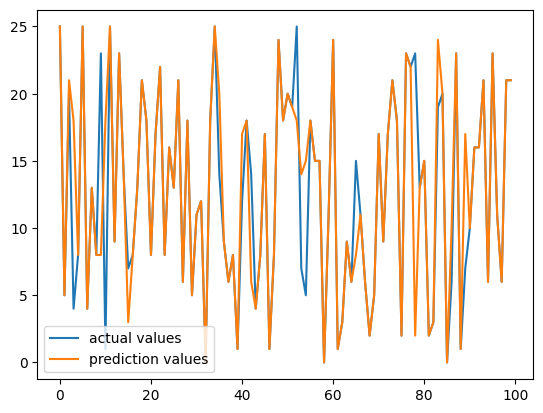

In [17]:
import matplotlib.pyplot as plt
plt.plot(actualclass[:100],label='actual values')
plt.plot(predclass[:100],label='prediction values')
plt.legend()
plt.show